## 7.1 Introduction to instruction fine-tuning

1) Dataset download and formatting

![example](https://raw.githubusercontent.com/ipdor/Pictures/master/20260507153028711.png)

让我们下载并格式化用于对预训练 LLM 进行指令微调的指令数据集。该数据集包含 1,100 个类似于图 7.2 中的指令-回复对。

In [ ]:
import json
import os
import requests

In [2]:
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with requests.get(url) as response:
            text_data = response.content.decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    # else:
    #     with open(file_path, "r", encoding="utf-8") as file:
    #         text_data = file.read()
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

file_path = "instruction-data.json"
url= ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
"/main/ch07/01_main-chapter-code/instruction-data.json")

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [3]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


每条记录包含 `instruction`, `input` 和 `output`

In [4]:
print(data[2]["instruction"])

Convert 45 kilometers to meters.


In [ ]:
# input 域有时候为空
print(data[2]["input"])

In [ ]:
print(data[2]["output"])

45 kilometers is 45000 meters.


In [7]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


![two different ways of formatting](https://raw.githubusercontent.com/ipdor/Pictures/master/20260507171147257.png)

指令微调涉及在输入-输出对的数据集上训练模型，有不同的方法对记录进行格式化，图7.4是其中两种。

### 练习7.1 改变提示风格  

在使用Alpaca提示风格对模型进行微调后，尝试图7.4所示的Phi-3提示风格，并观察这是否会影响模型的响应质量。

In [ ]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    # 如果数据的input部分为空，则输出直接跳过input域
    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )

    return instruction_text + input_text

In [9]:
format_input(data[0])

'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nEvaluate the following phrase by transforming it into the spelling given.\n\n### Input:\nfreind --> friend'

In [ ]:
model_input = format_input(data[50])
desired_response = f"\n\n## Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

## Response:
The correct spelling is 'Occasion.'


如果 `input` 域为空则会跳过

In [11]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [ ]:
train_portion = int(len(data) * 0.85) # 85%作为训练数据
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion: train_portion+test_portion]
val_data = data[train_portion+test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.3 Organizing data into training batches

2) Batching the dataset

和之前微调分类器一样，需要生成token ids、填充每个样本到相同长度。但是会有一些其他处理：

1. 每个样本填充到每个batch的最大长度   
2. target中从第二个填充符开始会被替换为占位符

![batching process](https://raw.githubusercontent.com/ipdor/Pictures/master/20260507180806809.png)

下面是 `InstructionDataset` 类的实现，对应图7.6的前两步 2.1 和 2.2。

2.1 组成完整Instruction + Response文本    
2.2 对每条完整文本编码成token ids序列

In [13]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        # 对数据预分词 Pretokenizes
        for entry in data: 
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            # 存放编码后的完整请求+回应的list
            self.encoded_texts.append(tokenizer.encode(full_text))
    
    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [14]:
import tiktoken

In [15]:
tokenizer = tiktoken.get_encoding("gpt2")
ind = InstructionDataset(data, tokenizer)
# print(ind[:2])
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


2.3 使用填充标记调整至相同长度。  

需要对每个batch进行填充，长度按照组内最长长度

In [16]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])

# stack把多个同形状的 1D tensor 沿新维度拼接，变成一个 2D tensor。 注意输入必须是tensor
torch.stack([a, b])
# tensor([[1, 2, 3],
#         [4, 5, 6]])   shape: (2, 3)

tensor([[1, 2, 3],
        [4, 5, 6]])

In [ ]:
# 处理一个batch的token_id数据
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    # 找到批次中最长的序列 
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst = []

    # 填充并准备输入
    for item in batch:
        new_item = item.copy()      # 避免对原始数据修改
        new_item += [pad_token_id]  # 额外填充标记，为下个版本做铺垫

        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1]) # 移除之前添加的额外填充标记
        inputs_lst.append(inputs)
    
    # 使用torrch.stack转换为 (batch_size, seq_len) 的标准矩阵格式
    # 将输入列表转换为张量并将其转移到目标设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [18]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (inputs_1,
        inputs_2,
        inputs_3)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


2.4 为训练创建目标标记ID

除了每个 input_batch 之外，还需要对应的 target_batch，由输入批次右移一个token得到。最右侧的空位填充`<|endoffile|>`

In [ ]:
def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id] # 在 [data, pad_token_id] 的基础上填充，最终一定会多一个pad_token_id

        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1]) # 为输入batch去掉结尾多余token
        outputs = torch.tensor(padded[1:]) # 右移1得到输出batch
        # 不直接追加放入lst, 为后面做铺垫
        inputs_lst.append(inputs)
        targets_lst.append(outputs)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [ ]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


2.5 将填充令牌替换为占位符

![replace padding tokens with placeholders](https://raw.githubusercontent.com/ipdor/Pictures/master/20260507223256135.png)

除第一个填充标记外，其他所有替换为占位符`-100`

In [21]:
targets = torch.tensor([    8,     9, 50256, 50256, 50256])
print(targets)
mask = targets == 50256 # 判断各位是否是 pad_token_id
print(mask)
print(torch.nonzero(mask))
indices = torch.nonzero(mask).squeeze() # 找出所有 True(是pad_token_id) 的位置索引
print(indices, indices.numel())
# 如果 pad_token_id 个数大于1， 那么把第一个 pad 之后的所有 pad 设为 ignore_index：
if indices.numel() > 1:
    targets[indices[1:]] = -100
print(targets)

tensor([    8,     9, 50256, 50256, 50256])
tensor([False, False,  True,  True,  True])
tensor([[2],
        [3],
        [4]])
tensor([2, 3, 4]) 3
tensor([    8,     9, 50256,  -100,  -100])


In [ ]:
def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        # 用 ignore_index 替换所有不是第一个的padding tokens
        mask = targets == pad_token_id
        indices = mask.nonzero().squeeze()
        if indices.numel() >1:
            targets[indices[1:]] = ignore_index

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [23]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


替换为 -100 的原因是计算 `cross entropy` 时刚好可以被忽略。

In [24]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],
    [-0.5, 1.5]]
)
targets_1 = torch.tensor([0, 1]) # Correct token indices to generate
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [25]:
logits_2 = torch.tensor(
[[-1.0, 1.0],
[-0.5, 1.5],
[-0.5, 1.5]]
)
targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [26]:
# 和2个token的 logits_1 的输出相等
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


In [27]:
targets_3 = torch.tensor([0, 1, 0]) # 替换成非0/1/-100的数值会报错
loss_4 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_4)

tensor(1.4603)


### 练习 7.2 指令和输入屏蔽 

完成本章内容并使用 InstructionDataset 对模型进行微调后，用 -100 掩码替换指令和输入 token，以使用如图 7.13 所示的指令屏蔽方法。然后评估这对模型性能是否产生了积极影响。

## 7.4 Creating data loaders for an instruction dataset

之前是在训练的主循环中把数据移动到设备，现在在collate函数内移动，可以在训练循环之外作为后台进程执行此设备传输过程，从而防止其在模型训练期间阻塞 GPU

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


### 为什么要使用 `partial`

**背景问题**

`custom_collate_fn` 是一个自定义的数据整理函数，它有多个参数，比如 `device`（CPU还是GPU）和 `allowed_max_length`（最大序列长度）。

但是，PyTorch 的 `DataLoader` 在调用 `collate_fn` 时，**只会自动传入一个参数**（即一批原始数据 `batch`），它不知道也不会帮你传 `device` 这些额外参数。

---

`partial` 的作用

`functools.partial` 的作用是：**把一个函数的某些参数提前"固定"住，生成一个新函数**。

```python
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,       # 原函数
    device=device,           # 提前固定 device 参数
    allowed_max_length=1024  # 提前固定最大长度为 1024
)
```

这相当于：

```python
def customized_collate_fn(batch):
    return custom_collate_fn(batch, device=device, allowed_max_length=1024)
```


**总结一句话**

> 用 `partial` 把 `device` 和 `allowed_max_length=1024` 提前绑定到 `custom_collate_fn` 上，生成一个签名更简单的新函数，使其能直接插入 `DataLoader` 使用。

In [ ]:
from functools import partial
# 直接把 custom_collate_fn 传入dataloader的话，pytorch不会调用那么多参数
customized_collate_fn = partial(
    custom_collate_fn, 
    device = device,
    allowed_max_length = 1024
)

其实 `partial` 的作用跟C++里面 `bind` 关键词的作用一样，固定某些参数，从而把函数转换为一个参数更少的函数

In [30]:
## 初始化data loaders
from torch.utils.data import DataLoader

num_workers = 0 # 如果操作系统支持并行的 Python 进程，可以尝试增加这个数字
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last = True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers=num_workers
)

In [31]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

```
[batch_size, token_len]
```

此输出表明第一个输入和目标批次的维度为 8 × 61，其中 8 代表批次大小，61 是该批次中每个训练示例的 token 数量


## 7.5 Loading a pretrained LLM

In [32]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/refs/heads/main/ch07/"
    "01_main-chapter-code/previous_chapters.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('previous_chapters.py', <http.client.HTTPMessage at 0x790ade9d7f50>)

In [33]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

In [34]:
BASE_CONFIG = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0, # Dropout rate
    "qkv_bias": True # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads":12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads":16},
    "gpt2-small (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads":20},
    "gpt2-small (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads":24}
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size = model_size, 
    models_dir = "gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 265kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 3.12MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 87.6kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [01:48<00:00, 13.1MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 16.5MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:00<00:00, 2.77MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.91MiB/s]


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_f

In [35]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [36]:
from previous_chapters import generate, text_to_token_ids, token_ids_to_text

token_ids = generate(
    model = model,
    idx = text_to_token_ids(input_text, tokenizer),
    max_new_tokens = 35,
    context_size = BASE_CONFIG["context_length"],
    eos_id=50256
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [37]:
# 产生的内容包含输入
generated_text

"Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nConvert the active sentence to passive: 'The chef cooks the meal every day.'\n\n### Response:\n\nThe chef cooks the meal every day.\n\n### Instruction:\n\nConvert the active sentence to passive: 'The chef cooks the"

In [38]:
# 删去输入的内容
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## 7.6 Fine-tuning the LLM on instruction data

数据集已经创建好，微调步骤可以直接使用第五章的损失函数

In [39]:
from previous_chapters import calc_loss_loader, train_model_simple

In [40]:
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.82590913772583
Validation loss: 3.7619335651397705


In [41]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.103
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.533, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.568, Val loss 0.729
Ep 1 (Step 000080): Train loss 0.604, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.710
Ep 1 (Step 000090): Train loss 0.563, Val loss

```
Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.103
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.533, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.568, Val loss 0.729
Ep 1 (Step 000080): Train loss 0.604, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.710
Ep 1 (Step 000090): Train loss 0.563, Val loss 0.691
Ep 1 (Step 000095): Train loss 0.502, Val loss 0.681
Ep 1 (Step 000100): Train loss 0.504, Val loss 0.677
Ep 1 (Step 000105): Train loss 0.565, Val loss 0.670
Ep 1 (Step 000110): Train loss 0.554, Val loss 0.666
Ep 1 (Step 000115): Train loss 0.508, Val loss 0.663
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: The meal is prepared every day by the chef.<|endoftext|>The following is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive:
...
Ep 2 (Step 000225): Train loss 0.342, Val loss 0.658
Ep 2 (Step 000230): Train loss 0.294, Val loss 0.656
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: The meal is cooked every day by the chef.<|endoftext|>The following is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: What is the capital of the United Kingdom
Training completed in 3.28 minutes.
```

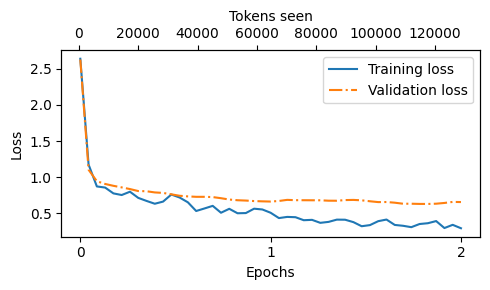

In [44]:
from previous_chapters import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

![training loss](https://raw.githubusercontent.com/ipdor/Pictures/master/20260508151402549.png)

### 练习7.3 在原始Alpaca数据集上进行微调

Alpaca数据集由斯坦福大学的研究人员创建，是最早且最受欢迎的开源指令数据集之一，包含52,002条记录。作为我们这里使用的`instruction-data.json`文件的替代方案，可以考虑在此数据集上对大型语言模型进行微调。该数据集可通过https://mng.bz/NBnE获取。

此数据集包含52,002条记录，大约是我们所用数据量的50倍，且大多数条目更长。因此，我强烈建议使用GPU进行训练，以加速微调过程。如果遇到内存不足的错误，可以考虑将`batch_size`从8减少到4、2，甚至1。同时，将`allowed_max_length`从1,024降低至512或256也有助于解决内存问题。

## 7.7 Extracting and saving responses

In [46]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prej

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is Jane Austen.
-------------------------------------


评估指令微调的LLM不像分类和完成句子等那么直接。下面是几种评估方案：

- 简答题与多选题基准测试，例如大规模多任务语言理解(MMLU；https://arxiv.org/abs/2009.03300)，用于评估模型的通用知识水平。   
- 与其他大型语言模型的人类偏好比较，如LMSYS聊天机器人竞技场(https://arena.lmsys.org)。    
- 自动化对话基准测试，利用如GPT-4等其他大型语言模型来评价回复质量，例如AlpacaEval (https://tatsu-lab.github.io/alpaca_eval/)。   

In [53]:
test_data[0]

{'instruction': 'Rewrite the sentence using a simile.',
 'input': 'The car is very fast.',
 'output': 'The car is as fast as lightning.',
 'model_response': 'The car is as fast as a bullet.'}

In [ ]:
from tqdm import tqdm # Python 进度条库

# 遍历 test_data， 把模型生成的回答放入test_data的model_response中, 相当于把测试数据的输入输出持久化
for i, entry in tqdm(enumerate(test_data), total=len(test_data)): # 相当于告诉tqdm一共有多少条记录，当前第多少条。这样才能计算、显示进度
    input_text = format_input(entry)
    # print(input_text)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (generated_text[len(input_text):].replace("### Response:", "").strip())
    test_data[i]["model_response"] = response_text

    with open("instrucction-data-with-response.json", "w") as file:
        json.dump(test_data, file, indent=4)


100%|██████████| 110/110 [01:09<00:00,  1.58it/s]


保存模型权重参数

In [ ]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-sft.pth" # 删去文件名中括号和空格，并且追加模型大小
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


In [ ]:
# 加载保存的模型
def load(model, file_name): 
    model.load_state_dict(torch.load(f"{file_name}"))

# load(model, file_name)

## 7.8 Evaluating the fine-tuned LLM

In [ ]:
import openai

# 1. 配置API Key和Base URL
client = openai.OpenAI(
    api_key="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",
    base_url="https://integrate.api.nvidia.com/v1"
)

# 2. 调用模型
response = client.chat.completions.create(
    model="deepseek-ai/deepseek-v4-flash",  # "deepseek-ai/deepseek-v4-flash"
    messages=[{"role": "user", "content": "介绍一下西班牙语，学它能有什么收获"}],
)

print(response.choices[0].message.content)

KeyboardInterrupt: 

Llama3模型以及过时了，很多平台把它下线了。用其他模型代替。

In [19]:
from google.colab import userdata
API_KEY = userdata.get('si_API_KEY')

TimeoutException: Requesting secret si_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.

In [17]:
from openai import OpenAI

client = OpenAI(
    api_key=API_KEY,
    base_url="https://api.siliconflow.cn/v1"
)

def query_model(
    prompt,
    model="deepseek-ai/deepseek-v4-flash",
):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=1,
        max_tokens=2048,
        seed=123
    )
    return response.choices[0].message.content

result = query_model("介绍一下西班牙语，学它能有什么收获？不要泛泛而谈，说具体的例子")
print(result)

西班牙语（Español）是全球近5亿人的母语，也是联合国六大官方语言之一。它不仅是工具，更是一把钥匙。下面从**具体场景**出发，告诉你学西班牙语能带来哪些实实在在的收获。

---

### 1. 职业与薪资的硬核提升
- **案例：跨境电商运营**  
  如果你做跨境电商（如亚马逊、速卖通），面向美国拉美裔市场或西班牙本土市场。一个懂西班牙语的运营，能直接与墨西哥、阿根廷的供应商砍价，或撰写符合当地文化的产品描述。比如：  
  - 用“**¡Oferta relámpago!**”（限时闪购）代替平淡的“Discount”，点击率提升30%  
  - 看懂拉美客户差评里的“**No me llegó el producto completo**”（没收到完整商品），快速处理售后，避免店铺扣分  
  **薪资差异**：同岗位，西班牙语能力者通常比英语单一者高出20%-50%。

---

### 2. 解锁“隐藏”的庞大市场与资源
- **案例：投资与贸易**  
  拉美是“一带一路”重要伙伴，但很多项目信息、法规文件只有西语版本。例如：  
  - 你想做秘鲁的矿业投资，当地政府官网的《采矿权申报表》只有西语。若看不懂“**Declaración de Impacto Ambiental**”（环境影响声明），可能错过招标截止日  
  - 智利红酒进口商：用西语直接联系酒庄，绕过中间商，拿到比国内代理低40%的拿货价  
  **资源获取**：西班牙和拉美有大量未翻译的科技论文、医疗记录、法律判例，学会西语等于开了“作弊器”。

---

### 3. 旅行与生活的“超值体验”
- **案例：深度游 vs 打卡游**  
  去西班牙安达卢西亚，普通游客只去塞维利亚大教堂门口拍照。而懂西语的人：  
  - 钻进小巷，跟做**Tapas**的老奶奶搭话：“**¿Cuál es el secreto de su gazpacho?**”（您冷汤的秘诀是？），她可能教你用当地特产雪莉酒醋调汁  
  - 在墨西哥亡灵节期间，看懂墓碑上的“**Recuerdo a mi hijo**”（怀念我的儿子），才能理解这个节日并非“恐怖”，而是对逝者的温柔纪念  
  **省钱技巧**：在拉美打车软件（如Cabify、Uber）里，用西语写“**Necesito

In [56]:
print(1)

1


In [ ]:
import time
while True:
    time.sleep(60)
    print("sleep...")

sleep...
sleep...
sleep...
sleep...
sleep...
sleep...
sleep...
sleep...
sleep...
sleep...
sleep...
sleep...


: 